In [ ]:
!pip -q install xarray
!mkdir -p data/raw


In [ ]:
!pip uninstall -y transformers
!pip install -U accelerate bitsandbytes torchvision pillow
!pip install "transformers @ git+https://github.com/huggingface/transformers.git@main"

  Cloning https://github.com/huggingface/transformers.git (to revision main) to /tmp/pip-install-n6hgp719/transformers_1ce94261cf9846429133cff9580acbe2
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-install-n6hgp719/transformers_1ce94261cf9846429133cff9580acbe2
  Resolved https://github.com/huggingface/transformers.git to commit 6133195dcb027feb7502379acd13750e167eb6c5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.3.0.dev0-py3-none-any.whl size=11327481 sha256=3ad301bba18747955869bee995503819348169064fc5b1f0389a4a4a1284e231
  Stored in directory: /tmp/pip-ephem-wheel-cache-z_m5u534/wheels/12/51/df/b62c8ce0479c5de6f7bef121169b3e946949a57481169d3155
Successfully built transformers


Среда и зависимости

In [ ]:
import calendar
import gzip
import io
import json
import re
import shutil
import subprocess
import uuid
import warnings
from contextlib import redirect_stdout
from copy import deepcopy
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, TypedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from google.colab import userdata
from huggingface_hub import login
from langgraph.graph import END, START, StateGraph
from transformers import AutoModelForCausalLM, AutoModelForSeq2SeqLM, AutoTokenizer, BitsAndBytesConfig, pipeline

warnings.filterwarnings('ignore')


# Сбор данных TEC

**Парсер IONEX-файлов**

**Загрузка и разбор исходных файлов**

In [ ]:
_NUM_RE = re.compile(r"[-+]?\d+(?:\.\d+)?(?:[DEde][-+]?\d+)?")

def _nums_from_line(line: str, n: int | None = None):

    txt = line[:60].replace("D", "E").replace("d", "E")
    nums = [float(x) for x in _NUM_RE.findall(txt)]
    return nums if n is None else nums[:n]

def parse_ionex_to_xarray(path: str | Path, keep_raw_int=False) -> xr.DataArray:
    path = Path(path)
    lines = path.read_text(errors="ignore").splitlines()

    lat1 = lat2 = dlat = None
    lon1 = lon2 = dlon = None
    exponent = 0
    i = 0

    while i < len(lines):
        line = lines[i]
        if "END OF HEADER" in line:
            i += 1
            break

        if "LAT1 / LAT2 / DLAT" in line:
            lat1, lat2, dlat = _nums_from_line(line, 3)

        if "LON1 / LON2 / DLON" in line:
            lon1, lon2, dlon = _nums_from_line(line, 3)

        if "EXPONENT" in line:
            exponent = int(_nums_from_line(line, 1)[0])

        i += 1

    if any(x is None for x in [lat1, lat2, dlat, lon1, lon2, dlon]):
        raise ValueError("Не удалось прочитать сетку lat/lon из заголовка.")

    lat = np.arange(lat1, lat2 + (dlat/2), dlat)
    lon = np.arange(lon1, lon2 + (dlon/2), dlon)

    def parse_epoch(line: str) -> datetime:
        vals = _nums_from_line(line, 6)
        y, mo, d, hh, mm, ss = map(int, vals)
        return datetime(y, mo, d, hh, mm, ss)

    times = []
    maps = []

    while i < len(lines):
        line = lines[i]

        if "START OF TEC MAP" in line:
            cur_epoch = None
            grid = np.full((len(lat), len(lon)), np.nan, dtype=float)
            i += 1

            while i < len(lines):
                line = lines[i]

                if "EPOCH OF CURRENT MAP" in line:
                    cur_epoch = parse_epoch(line)
                    i += 1
                    continue

                if "LAT/LON1/LON2/DLON/H" in line:

                    lat_v, lon1_v, lon2_v, dlon_v, h_v = _nums_from_line(line, 5)
                    lat_idx = int(np.argmin(np.abs(lat - lat_v)))

                    vals = []
                    i += 1
                    while i < len(lines):
                        nxt = lines[i]
                        if ("LAT/LON1/LON2/DLON/H" in nxt) or ("END OF TEC MAP" in nxt):
                            break
                        vals.extend(_nums_from_line(nxt))
                        i += 1

                    arr = np.array(vals[:len(lon)], dtype=float)
                    if arr.size < len(lon):
                        arr = np.pad(arr, (0, len(lon) - arr.size), constant_values=np.nan)

                    grid[lat_idx, :] = arr
                    continue

                if "END OF TEC MAP" in line:
                    if cur_epoch is None:
                        raise ValueError("TEC MAP без EPOCH OF CURRENT MAP.")
                    times.append(cur_epoch)
                    maps.append(grid)
                    break

                i += 1

        i += 1

    if len(maps) == 0:
        raise ValueError("Не найдено ни одной TEC MAP в файле.")

    data = np.stack(maps, axis=0)

    scale = 10.0 ** exponent
    if not keep_raw_int:
        data = data * scale

    da = xr.DataArray(
        data,
        coords={"time": pd.to_datetime(times), "lat": lat, "lon": lon},
        dims=("time", "lat", "lon"),
        name="vtec",
        attrs={
            "source_file": str(path),
            "ionex_exponent": exponent,
            "units": "TECU" if not keep_raw_int else f"raw*10^{exponent}",
            "product": "CODE GIM (COD0OPSFIN) via IGS/BKG mirror",
        }
    )
    return da

**Региональные средние по каждому часу**

*Формирование региональных временных рядов*

In [ ]:

REGIONS = {

    "equatorial_atlantic": {"lat": (-15, 15), "lon": (-60, 0)},
    "equatorial_africa":   {"lat": (-15, 15), "lon": (0, 40)},
    "equatorial_pacific":  {"lat": (-15, 15), "lon": (140, -120)},

    "eia_south_america": {"lat": (-25, -5), "lon": (-80, -35)},
    "eia_asia":          {"lat": (5, 25),   "lon": (90, 140)},

    "midlat_europe": {"lat": (35, 60), "lon": (-10, 40)},
    "midlat_usa":    {"lat": (30, 55), "lon": (-130, -65)},
    "midlat_asia":   {"lat": (35, 60), "lon": (60, 120)},

    "midlat_south_america": {"lat": (-55, -30), "lon": (-75, -40)},
    "midlat_australia":     {"lat": (-45, -20), "lon": (110, 160)},

    "highlat_north": {"lat": (65, 82.5), "lon": (-180, 180)},
    "highlat_south": {"lat": (-82.5, -65), "lon": (-180, 180)},
}

In [ ]:
def select_region(da, lat_range, lon_range):
    lat1, lat2 = lat_range
    lon1, lon2 = lon_range

    lat_slice = slice(min(lat1, lat2), max(lat1, lat2))
    lon_slice = slice(min(lon1, lon2), max(lon1, lon2))

    sub = da.sel(lat=lat_slice, lon=lon_slice)
    return sub

def region_timeseries(da, region):
    sub = select_region(da, region["lat"], region["lon"])
    ts = sub.mean(dim=("lat", "lon"), skipna=True)
    return ts

def gps_week(dt: datetime) -> int:
    gps0 = datetime(1980, 1, 6)
    return (dt - gps0).days // 7

**Выбор анализируемого временного диапазона**

In [ ]:
def date_range(start, end):
    cur = start
    while cur < end:
        yield cur
        cur += timedelta(days=1)

def download_codg_day(dt: datetime, out_dir="data/raw"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    year = dt.year
    doy = dt.timetuple().tm_yday
    week = gps_week(dt)

    fname = f"COD0OPSFIN_{year}{doy:03d}0000_01D_01H_GIM.INX.gz"
    url = f"https://igs.bkg.bund.de/root_ftp/IGSac/products/{week}/{fname}"

    gz_path = out_dir / fname
    inx_path = gz_path.with_suffix("")

    if inx_path.exists():
        return inx_path

    subprocess.check_call(["wget", "-q", "-O", str(gz_path), url])

    with gzip.open(gz_path, "rb") as f_in, open(inx_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

    return inx_path

In [ ]:
start = datetime(2024, 4, 1)
end   = datetime(2024, 4, 30)

daily_arrays = []

for dt in date_range(start, end):
    try:
        inx = download_codg_day(dt)
        da_day = parse_ionex_to_xarray(inx)

        da_day = da_day.sortby("lat")
        daily_arrays.append(da_day)
        print("OK:", dt.date())
    except Exception as e:
        print("FAIL:", dt.date(), e)

OK: 2024-04-01
OK: 2024-04-02
OK: 2024-04-03
OK: 2024-04-04
OK: 2024-04-05
OK: 2024-04-06
OK: 2024-04-07
OK: 2024-04-08
OK: 2024-04-09
OK: 2024-04-10
OK: 2024-04-11
OK: 2024-04-12
OK: 2024-04-13
OK: 2024-04-14
OK: 2024-04-15
OK: 2024-04-16
OK: 2024-04-17
OK: 2024-04-18
OK: 2024-04-19
OK: 2024-04-20
OK: 2024-04-21
OK: 2024-04-22
OK: 2024-04-23
OK: 2024-04-24
OK: 2024-04-25
OK: 2024-04-26
OK: 2024-04-27
OK: 2024-04-28
OK: 2024-04-29


In [ ]:
da_month = xr.concat(daily_arrays, dim="time")
da_month

<xarray.DataArray 'vtec' (time: 725, lat: 71, lon: 73)> Size: 30MB
array([[[11.7, 11.5, 11.4, ...,  nan,  nan,  nan],
        [13. , 12.8, 12.6, ...,  nan,  nan,  nan],
        [14.3, 14.1, 14. , ...,  nan,  nan,  nan],
        ...,
        [27.6, 28.2, 28.8, ...,  nan,  nan,  nan],
        [28.6, 29. , 29.3, ...,  nan,  nan,  nan],
        [28.5, 28.7, 28.8, ...,  nan,  nan,  nan]],

       [[12.7, 12.5, 12.4, ...,  nan,  nan,  nan],
        [14.4, 14.1, 13.9, ...,  nan,  nan,  nan],
        [16.2, 15.8, 15.5, ...,  nan,  nan,  nan],
        ...,
        [28.1, 28.4, 28.6, ...,  nan,  nan,  nan],
        [27.7, 27.9, 28.1, ...,  nan,  nan,  nan],
        [26.4, 26.5, 26.6, ...,  nan,  nan,  nan]],

       [[16.7, 16.5, 16.4, ...,  nan,  nan,  nan],
        [19.2, 18.8, 18.5, ...,  nan,  nan,  nan],
        [21.1, 20.6, 20.2, ...,  nan,  nan,  nan],
        ...,
...
        ...,
        [23.1, 23.3, 23.5, ...,  nan,  nan,  nan],
        [24.7, 24.9, 25.1, ...,  nan,  nan,  nan],
        [25.4, 25.5, 25.6, ...,  nan,  nan,  nan]],

       [[ 8.1,  8. ,  8. , ...,  nan,  nan,  nan],
        [10.7, 10.7, 10.6, ...,  nan,  nan,  nan],
        [12.9, 12.8, 12.8, ...,  nan,  nan,  nan],
        ...,
        [22.9, 23. , 23.2, ...,  nan,  nan,  nan],
        [24.4, 24.5, 24.8, ...,  nan,  nan,  nan],
        [24.9, 25. , 25.1, ...,  nan,  nan,  nan]],

       [[ 8. ,  7.9,  7.8, ...,  nan,  nan,  nan],
        [10. ,  9.8,  9.7, ...,  nan,  nan,  nan],
        [11.6, 11.5, 11.4, ...,  nan,  nan,  nan],
        ...,
        [23.8, 23.9, 24. , ...,  nan,  nan,  nan],
        [24.5, 24.6, 24.8, ...,  nan,  nan,  nan],
        [24.4, 24.5, 24.6, ...,  nan,  nan,  nan]]])
Coordinates:
  * time     (time) datetime64[ns] 6kB 2024-04-01 ... 2024-04-30
  * lat      (lat) float64 568B -87.5 -85.0 -82.5 -80.0 ... 80.0 82.5 85.0 87.5
  * lon      (lon) float64 584B -180.0 -175.0 -170.0 ... 170.0 175.0 180.0
Attributes:
    source_file:     data/raw/COD0OPSFIN_20240920000_01D_01H_GIM.INX
    ionex_exponent:  -1
    units:           TECU
    product:         CODE GIM (COD0OPSFIN) via IGS/BKG mirror

In [ ]:
!pip install cartopy ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.5 MB/s eta 0:00:00


In [ ]:
# Если нужно:
# !pip install cartopy ipywidgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from ipywidgets import interact, IntSlider

da = da_month.copy().sortby("time").sortby("lat").sortby("lon")

if float(da.lon.max()) > 180:
    new_lon = (((da.lon + 180) % 360) - 180)
    da = da.assign_coords(lon=new_lon).sortby("lon")

times = pd.to_datetime(da.time.values)

vmin = float(np.nanpercentile(da.values, 2))
vmax = float(np.nanpercentile(da.values, 98))

def plot_tec_map(time_idx=0):
    cur = da.isel(time=time_idx)
    t = pd.Timestamp(cur.time.values)

    fig = plt.figure(figsize=(15, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())

    mesh = ax.pcolormesh(
        cur.lon.values,
        cur.lat.values,
        cur.values,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="turbo",
        vmin=vmin,
        vmax=vmax
    )

    ax.coastlines(resolution="110m", linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, alpha=0.15)
    ax.add_feature(cfeature.OCEAN, alpha=0.05)
    ax.set_global()

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"Global TEC map | {t.strftime('%Y-%m-%d %H:%M UTC')}", fontsize=14)

    cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label("VTEC, TECU")

    plt.show()

interact(
    plot_tec_map,
    time_idx=IntSlider(
        min=0,
        max=len(times) - 1,
        step=1,
        value=0,
        description="time"
    )
)

interactive(children=(IntSlider(value=0, description='time', max=724), Output()), _dom_classes=('widget-intera…

<function __main__.plot_tec_map(time_idx=0)>

> Проверка целостности и размерностей

Краткая валидация подготовленных данных

In [ ]:
print("time size:", da_month.time.size)
print("unique time:", np.unique(da_month.time.values).size)

time size: 2225
unique time: 2137


In [ ]:
sizes = [da.time.size for da in daily_arrays]
print("min/max per day:", min(sizes), max(sizes))

min/max per day: 25 25


In [ ]:
print("time range:", da_month.time.min().values, da_month.time.max().values)
print("shape:", da_month.shape)

time range: 2024-02-01T00:00:00.000000000 2024-04-30T00:00:00.000000000
shape: (2225, 71, 73)


In [ ]:
df_ts = pd.DataFrame({
    name: region_timeseries(da_month, reg).to_pandas()
    for name, reg in REGIONS.items()
})
df_ts = df_ts.reset_index().drop_duplicates('time', keep = 'last').set_index('time')
print(len(df_ts))
df_ts.head()

2137


,equatorial_atlantic,equatorial_africa,equatorial_pacific,eia_south_america,eia_asia,midlat_europe,midlat_usa,midlat_asia,midlat_south_america,midlat_australia,highlat_north,highlat_south
time,,,,,,,,,,,,
2024-02-01 00:00:00,27.727811,14.493162,40.107521,38.634444,70.944444,7.911570,19.695455,26.263636,20.543182,NaN,13.068640,20.524342
2024-02-01 01:00:00,23.698225,17.737607,40.524444,34.846667,80.970370,8.910744,14.940260,28.876768,19.671591,NaN,13.135526,21.974342
2024-02-01 02:00:00,20.605917,25.483761,41.392137,30.098889,84.162963,11.735537,12.066234,30.728283,18.861364,NaN,12.961623,23.798246
2024-02-01 03:00:00,18.503550,35.307692,42.334359,27.415556,87.803704,16.100826,10.778571,31.215152,17.645455,NaN,12.710746,25.695614
2024-02-01 04:00:00,16.828994,45.510256,43.739316,23.997778,87.970370,20.438017,9.924675,29.989899,17.213636,NaN,12.528728,27.652851


## Визуализация

<Figure size 1000x400 with 0 Axes>

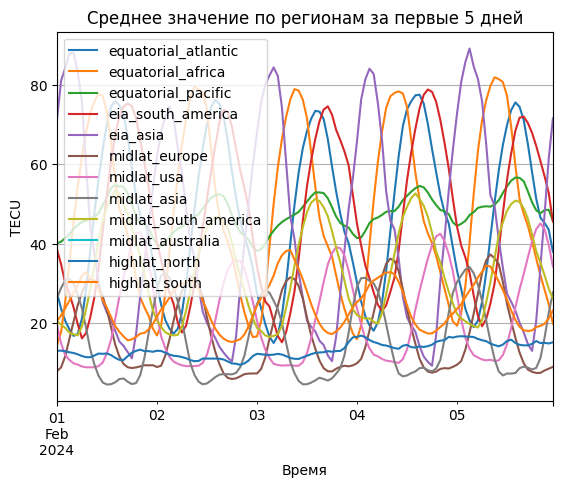

In [ ]:
plt.figure(figsize=(10,4))
df_ts[:24*5].plot()
plt.grid(True)
plt.title("Среднее значение по регионам за первые 5 дней")
plt.xlabel("Время")
plt.ylabel("TECU")
plt.show()

In [ ]:
df_ts.columns

Index(['equatorial_atlantic', 'equatorial_africa', 'equatorial_pacific',
       'eia_south_america', 'eia_asia', 'midlat_europe', 'midlat_usa',
       'midlat_asia', 'midlat_south_america', 'midlat_australia',
       'highlat_north', 'highlat_south'],
      dtype='object')

<Figure size 1000x400 with 0 Axes>

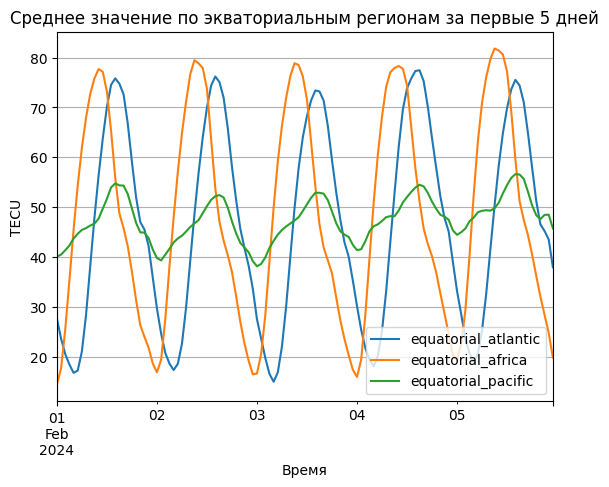

In [ ]:
plt.figure(figsize=(10,4))
df_ts[['equatorial_atlantic', 'equatorial_africa', 'equatorial_pacific']][:24*5].plot()
plt.grid(True)
plt.title("Среднее значение по экваториальным регионам за первые 5 дней")
plt.xlabel("Время")
plt.ylabel("TECU")
plt.show()

<Figure size 1000x400 with 0 Axes>

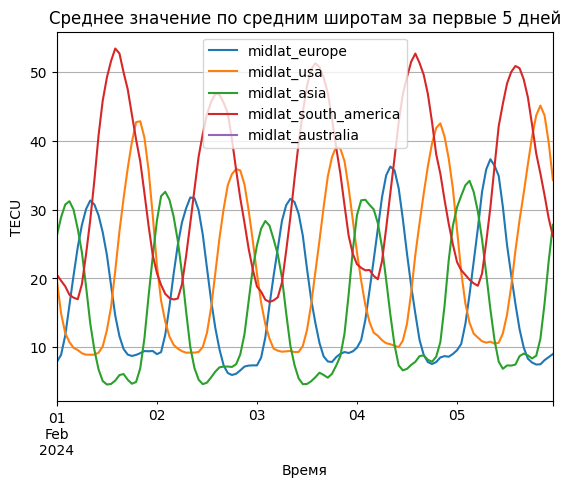

In [ ]:
plt.figure(figsize=(10,4))
df_ts[['midlat_europe', 'midlat_usa',
       'midlat_asia', 'midlat_south_america', 'midlat_australia']][:24*5].plot()
plt.grid(True)
plt.title("Среднее значение по средним широтам за первые 5 дней")
plt.xlabel("Время")
plt.ylabel("TECU")
plt.show()

<Figure size 1000x400 with 0 Axes>

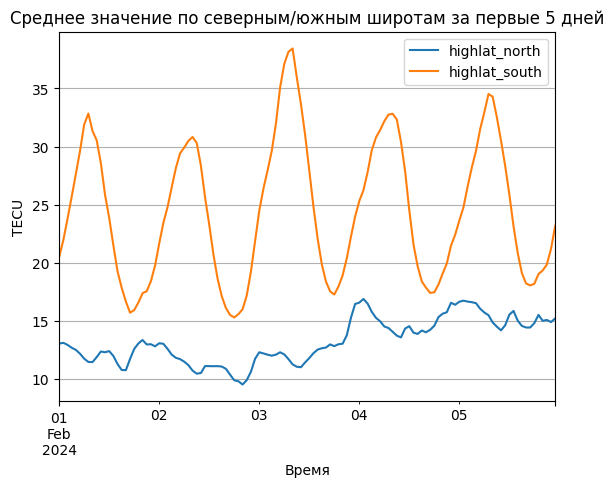

In [ ]:
plt.figure(figsize=(10,4))
df_ts[['highlat_north', 'highlat_south']][:24*5].plot()
plt.grid(True)
plt.title("Среднее значение по северным/южным широтам за первые 5 дней")
plt.xlabel("Время")
plt.ylabel("TECU")
plt.show()

In [ ]:
df_tec = df_ts.copy()
df_tec.index = pd.to_datetime(df_tec.index)
df_tec = df_tec.sort_index()

TEC_TABLE_STORE: Dict[str, pd.DataFrame] = {"default": df_tec}
SERIES_STORE: Dict[str, Dict[str, Any]] = {}
ALIGN_STORE: Dict[str, Dict[str, Any]] = {}

df_tec.head()

,equatorial_atlantic,equatorial_africa,equatorial_pacific,eia_south_america,eia_asia,midlat_europe,midlat_usa,midlat_asia,midlat_south_america,midlat_australia,highlat_north,highlat_south
time,,,,,,,,,,,,
2024-02-01 00:00:00,27.727811,14.493162,40.107521,38.634444,70.944444,7.911570,19.695455,26.263636,20.543182,NaN,13.068640,20.524342
2024-02-01 01:00:00,23.698225,17.737607,40.524444,34.846667,80.970370,8.910744,14.940260,28.876768,19.671591,NaN,13.135526,21.974342
2024-02-01 02:00:00,20.605917,25.483761,41.392137,30.098889,84.162963,11.735537,12.066234,30.728283,18.861364,NaN,12.961623,23.798246
2024-02-01 03:00:00,18.503550,35.307692,42.334359,27.415556,87.803704,16.100826,10.778571,31.215152,17.645455,NaN,12.710746,25.695614
2024-02-01 04:00:00,16.828994,45.510256,43.739316,23.997778,87.970370,20.438017,9.924675,29.989899,17.213636,NaN,12.528728,27.652851


# Агенты

## Одноагентный режим

Инициализация модели и токенизатора

In [ ]:
hf_token = userdata.get("HF_read_token")

login(token=hf_token)

In [ ]:
MODEL_NAME = "Qwen/Qwen3.5-4B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)

model.eval()
model.config.use_cache = True

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

In [ ]:
@torch.inference_mode()
def debug_chat_generate_raw(
    messages,
    tools=None,
    max_new_tokens=128,
    max_input_length=4096,
    enable_thinking=False,
):
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        tools=tools,
        enable_thinking=enable_thinking,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_length,
    ).to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id,
    )

    input_len = inputs["input_ids"].shape[1]
    gen_ids = out[0][input_len:]
    text_clean = tokenizer.decode(gen_ids, skip_special_tokens=True)

    return text_clean.strip()


In [ ]:
SYSTEM_PROMPT = """
You are a scientific assistant for ionospheric TEC (Total Electron Content) analysis.

Your task is to answer user questions by calling the available analytical tools.

All numeric computations MUST be performed using tools. Never invent numeric results.

====================
GENERAL PROTOCOL
====================

On each short reasoning step you must output exactly ONE of the following:

1) exactly one tool call block:

<tool_call>
<function=tool_name>
<parameter=name>value</parameter>
...
</function>
</tool_call>

OR

2) exactly this flag and nothing else:

<final_answer>

Rules:
- Never output two tool calls in one message.
- If you output a tool call, output NOTHING before or after it.
- If no more tools are needed, output exactly <final_answer>.
- Do not output the full final answer on a short reasoning step.
- Do not output reasoning, explanations, plans, role tags, or think tags.
- Never fabricate thresholds, statistics, or intervals.

====================
DATA HANDLES
====================

Tools return handles that must be reused in later tool calls.

Common handles:
- series_id returned by tec_get_timeseries
- threshold_id returned by tec_compute_high_threshold
- threshold_id returned by tec_compute_stability_thresholds
- aligned_id returned by tec_align_series

You MUST reuse the exact handle values returned by tools.
Never invent handle IDs such as "t1", "series_A", "stb_001", or similar placeholders.

====================
DATA ACCESS
====================

To load TEC data for a region use tec_get_timeseries.

Always use:
dataset_ref = "default"

====================
TASK ROUTES
====================

High TEC intervals:
tec_get_timeseries
-> tec_compute_high_threshold
-> tec_detect_high_intervals

Stable TEC intervals:
tec_get_timeseries
-> tec_compute_stability_thresholds
-> tec_detect_stable_intervals

If the user explicitly provides numeric stability criteria,
you may use:
tec_find_stable_intervals_direct

Summary/statistics:
tec_get_timeseries
-> tec_build_report_from_series

Optional:
tec_series_profile may be used if needed.

Comparison of two regions:
tec_get_timeseries for region A
-> tec_get_timeseries for region B
-> tec_align_series
-> tec_compare_series

====================
MINIMAL TOOL POLICY
====================

Use the minimal number of tool calls needed to solve the task.
Do not repeat a tool call unless the previous result was invalid.
When the available tool results are sufficient, output exactly <final_answer>.
"""


### Описание инструментов

In [ ]:
TEC_TABLE_STORE: Dict[str, pd.DataFrame] = TEC_TABLE_STORE
SERIES_STORE: Dict[str, Dict[str, Any]] = {}
REPORT_STORE: Dict[str, Dict[str, Any]] = {}
ALIGN_STORE: Dict[str, Dict[str, Any]] = {}
THRESHOLD_STORE: Dict[str, Dict[str, Any]] = {}

def _get_df(dataset_ref: str) -> pd.DataFrame:
    if dataset_ref not in TEC_TABLE_STORE:
        raise KeyError(f"Unknown dataset_ref: {dataset_ref}. Available: {list(TEC_TABLE_STORE.keys())}")
    df = TEC_TABLE_STORE[dataset_ref]
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("TEC table index must be a DatetimeIndex.")
    return df.sort_index()

def _to_index_tz(ts: pd.Timestamp, idx: pd.DatetimeIndex) -> pd.Timestamp:
    if idx.tz is None:
        if ts.tzinfo is not None:
            return ts.tz_convert("UTC").tz_localize(None)
        return ts
    else:
        if ts.tzinfo is None:
            return ts.tz_localize(idx.tz)
        return ts.tz_convert(idx.tz)

def _slice_series(df: pd.DataFrame, region: str, start: str, end: str) -> pd.Series:
    if region not in df.columns:
        raise KeyError(f"Unknown region column: {region}. Available: {list(df.columns)}")

    idx = df.index
    t0 = _to_index_tz(pd.to_datetime(start), idx)
    t1 = _to_index_tz(pd.to_datetime(end), idx)

    s = df.loc[(idx >= t0) & (idx < t1), region].astype(float).dropna()
    if s.empty:
        raise ValueError(f"No data for region={region} in range [{start}, {end})")
    return s

def _resample_if_needed(s: pd.Series, freq: Optional[str]) -> pd.Series:
    if not freq:
        return s
    freq_pd = freq.replace("h", "H")
    return s.resample(freq_pd).mean().dropna()

def _get_series(series_id: str) -> pd.Series:
    if series_id not in SERIES_STORE:
        raise KeyError(f"Unknown series_id: {series_id}")
    rec = SERIES_STORE[series_id]
    idx = pd.to_datetime(rec["index"])
    y = pd.Series(rec["values"], index=idx).astype(float).dropna()
    if y.empty:
        raise ValueError(f"Series {series_id} is empty after dropna")
    return y

def _estimate_step_minutes(y: pd.Series) -> Optional[float]:
    diffs = y.index.to_series().diff().dropna()
    if len(diffs) == 0:
        return None
    step_min = diffs.dt.total_seconds() / 60.0
    return float(step_min.median())

In [ ]:
def tec_get_timeseries(
    dataset_ref: str,
    region: str,
    start: str,
    end: str,
    tz: str = "UTC",
    freq: Optional[str] = None,
) -> Dict[str, Any]:
    if dataset_ref != "default":
        raise KeyError("Only dataset_ref='default' is allowed.")

    df = _get_df(dataset_ref)
    s = _slice_series(df, region, start, end)
    s = _resample_if_needed(s, freq)

    series_id = str(uuid.uuid4())[:8]
    SERIES_STORE[series_id] = {
        "series_name": region,
        "region": region,
        "tz": tz,
        "freq": freq,
        "index": s.index,
        "values": s.values,
    }

    return {
        "series_id": series_id,
        "series_name": region,
        "region": region,
        "start": str(s.index.min()),
        "end": str(s.index.max()),
        "n_points": int(len(s)),
        "approx_q90": float(np.quantile(s.values, 0.90)),
    }

In [ ]:
def tec_series_profile(series_id: str) -> Dict[str, Any]:
    y = _get_series(series_id)
    rec = SERIES_STORE[series_id]

    diffs = y.index.to_series().diff().dropna()
    if len(diffs) == 0:
        median_step_min = None
        step_jitter_min = None
        n_gaps = 0
        max_gap_min = 0.0
    else:
        step_min = diffs.dt.total_seconds() / 60.0
        median_step_min = float(step_min.median())
        step_jitter_min = float(step_min.std(ddof=0)) if len(step_min) > 1 else 0.0

        gap_thr = 2.0 * median_step_min if median_step_min else None
        if gap_thr:
            gaps = step_min[step_min > gap_thr]
            n_gaps = int(gaps.shape[0])
            max_gap_min = float(gaps.max()) if n_gaps else 0.0
        else:
            n_gaps = 0
            max_gap_min = 0.0

    t0, t1 = y.index.min(), y.index.max()
    span_min = float((t1 - t0).total_seconds() / 60.0) if t1 > t0 else 0.0
    if median_step_min and median_step_min > 0 and span_min > 0:
        expected = int(np.floor(span_min / median_step_min)) + 1
        coverage_ratio = float(min(1.0, y.shape[0] / max(1, expected)))
    else:
        expected = None
        coverage_ratio = None

    return {
        "series_id": series_id,
        "region": rec.get("region", rec.get("series_name", series_id)),
        "tz": rec.get("tz", "UTC"),
        "freq": rec.get("freq"),
        "start": str(t0),
        "end": str(t1),
        "n_points": int(y.shape[0]),
        "min": float(y.min()),
        "max": float(y.max()),
        "median_step_minutes": median_step_min,
        "step_jitter_minutes": step_jitter_min,
        "expected_points": expected,
        "coverage_ratio": coverage_ratio,
        "n_gaps": n_gaps,
        "max_gap_minutes": max_gap_min,
    }

In [ ]:
def tec_compute_high_threshold(
    series_id: str,
    method: str = "quantile",
    q: float = 0.90,
) -> Dict[str, Any]:
    y = _get_series(series_id)

    if method != "quantile":
        return {"error": "method must be 'quantile'"}

    thr = float(y.quantile(q))

    threshold_id = str(uuid.uuid4())[:8]
    THRESHOLD_STORE[threshold_id] = {
        "threshold_id": threshold_id,
        "kind": "high",
        "series_id": series_id,
        "method": method,
        "params": {"q": float(q)},
        "value": {"threshold": thr},
    }

    return {
        "threshold_id": threshold_id,
        "kind": "high",
        "series_id": series_id,
        "method": method,
        "q": float(q),
        "threshold": thr,
    }

def tec_compute_stability_thresholds(
    series_id: str,
    window_minutes: int = 180,
    method: str = "quantile",
    q_delta: float = 0.60,
    q_std: float = 0.60,
) -> Dict[str, Any]:
    y = _get_series(series_id)

    if method != "quantile":
        return {"error": "method must be 'quantile'"}

    step_min = _estimate_step_minutes(y)
    if not step_min or step_min <= 0:
        step_min = 60.0

    win_points = max(2, int(round(window_minutes / step_min)))

    dy = y.diff().abs().dropna()
    rolling_std = y.rolling(win_points, min_periods=win_points).std().dropna()

    max_delta = float(dy.quantile(q_delta)) if len(dy) else 0.0
    max_std = float(rolling_std.quantile(q_std)) if len(rolling_std) else 0.0

    threshold_id = str(uuid.uuid4())[:8]
    THRESHOLD_STORE[threshold_id] = {
        "threshold_id": threshold_id,
        "kind": "stable",
        "series_id": series_id,
        "method": method,
        "params": {"window_minutes": int(window_minutes), "q_delta": float(q_delta), "q_std": float(q_std)},
        "value": {"window_minutes": int(window_minutes), "max_delta": max_delta, "max_std": max_std},
    }

    return {
        "threshold_id": threshold_id,
        "kind": "stable",
        "series_id": series_id,
        "method": method,
        "window_minutes": int(window_minutes),
        "q_delta": float(q_delta),
        "q_std": float(q_std),
        "max_delta": max_delta,
        "max_std": max_std,
    }

In [ ]:
def tec_detect_high_intervals(
    series_id: str,
    threshold_id: str,
    min_duration_minutes: int = 30,
    merge_gap_minutes: int = 15,
) -> Dict[str, Any]:
    if threshold_id not in THRESHOLD_STORE:
        return {"error": f"Unknown threshold_id: {threshold_id}", "intervals": []}

    th = THRESHOLD_STORE[threshold_id]
    if th.get("kind") != "high":
        return {"error": "threshold_id kind mismatch (expected 'high')", "intervals": []}
    if th.get("series_id") != series_id:
        return {"error": "threshold_id was computed for a different series_id", "intervals": []}

    y = _get_series(series_id)
    thr = float(th["value"]["threshold"])

    mask = y >= thr
    if mask.sum() == 0:
        return {"series_id": series_id, "threshold_id": threshold_id, "threshold": thr, "intervals": []}

    is_start = mask & (~mask.shift(1, fill_value=False))
    is_end = mask & (~mask.shift(-1, fill_value=False))
    starts = y.index[is_start]
    ends = y.index[is_end]

    raw = []
    for st, en in zip(starts, ends):
        seg = y.loc[st:en]
        raw.append({
            "start": str(st),
            "end": str(en),
            "peak": float(seg.max()),
            "mean": float(seg.mean()),
            "n_points": int(seg.shape[0]),
        })

    gap = pd.Timedelta(minutes=merge_gap_minutes)
    merged = []
    for it in raw:
        if not merged:
            merged.append(it)
            continue
        prev = merged[-1]
        if pd.to_datetime(it["start"]) - pd.to_datetime(prev["end"]) <= gap:
            merged[-1] = {
                "start": prev["start"],
                "end": it["end"],
                "peak": max(prev["peak"], it["peak"]),
                "mean": float("nan"),
                "n_points": prev["n_points"] + it["n_points"],
            }
        else:
            merged.append(it)

    mind = pd.Timedelta(minutes=min_duration_minutes)
    merged2 = [it for it in merged if (pd.to_datetime(it["end"]) - pd.to_datetime(it["start"])) >= mind]

    return {
        "series_id": series_id,
        "threshold_id": threshold_id,
        "threshold": thr,
        "intervals": merged2,
    }

def tec_detect_stable_intervals(
    series_id: str,
    threshold_id: str,
    min_duration_minutes: int = 60,
    merge_gap_minutes: int = 15,
) -> Dict[str, Any]:
    if threshold_id not in THRESHOLD_STORE:
        return {"error": f"Unknown threshold_id: {threshold_id}", "intervals": []}

    th = THRESHOLD_STORE[threshold_id]
    if th.get("kind") != "stable":
        return {"error": "threshold_id kind mismatch (expected 'stable')", "intervals": []}
    if th.get("series_id") != series_id:
        return {"error": "threshold_id was computed for a different series_id", "intervals": []}

    y = _get_series(series_id)
    window_minutes = int(th["value"]["window_minutes"])
    max_delta = float(th["value"]["max_delta"])
    max_std = float(th["value"]["max_std"])

    step_min = _estimate_step_minutes(y)
    if not step_min or step_min <= 0:
        step_min = 60.0
    win_points = max(2, int(round(window_minutes / step_min)))

    dy = y.diff().abs()
    rolling_std = y.rolling(win_points, min_periods=win_points).std()

    cond = pd.Series(True, index=y.index)
    cond &= (dy.fillna(0.0) <= max_delta)
    cond &= (rolling_std <= max_std)
    cond = cond.fillna(False)

    if cond.sum() == 0:
        return {
            "series_id": series_id,
            "threshold_id": threshold_id,
            "stability_thresholds": {"window_minutes": window_minutes, "max_delta": max_delta, "max_std": max_std},
            "intervals": []
        }

    is_start = cond & (~cond.shift(1, fill_value=False))
    is_end = cond & (~cond.shift(-1, fill_value=False))
    starts = y.index[is_start]
    ends = y.index[is_end]

    raw = []
    for st, en in zip(starts, ends):
        seg = y.loc[st:en]
        raw.append({
            "start": str(st),
            "end": str(en),
            "mean": float(seg.mean()),
            "std": float(seg.std(ddof=0)) if seg.shape[0] > 1 else 0.0,
            "min": float(seg.min()),
            "max": float(seg.max()),
            "n_points": int(seg.shape[0]),
        })

    gap = pd.Timedelta(minutes=merge_gap_minutes)
    merged = []
    for it in raw:
        if not merged:
            merged.append(it)
            continue
        prev = merged[-1]
        if pd.to_datetime(it["start"]) - pd.to_datetime(prev["end"]) <= gap:
            merged[-1] = {
                "start": prev["start"],
                "end": it["end"],
                "mean": float("nan"),
                "std": float("nan"),
                "min": min(prev["min"], it["min"]),
                "max": max(prev["max"], it["max"]),
                "n_points": prev["n_points"] + it["n_points"],
            }
        else:
            merged.append(it)

    mind = pd.Timedelta(minutes=min_duration_minutes)
    merged2 = [it for it in merged if (pd.to_datetime(it["end"]) - pd.to_datetime(it["start"])) >= mind]

    return {
        "series_id": series_id,
        "threshold_id": threshold_id,
        "stability_thresholds": {"window_minutes": window_minutes, "max_delta": max_delta, "max_std": max_std},
        "intervals": merged2
    }

def tec_find_stable_intervals_direct(
    series_id: str,
    window_minutes: int,
    max_delta: float,
    max_std: float,
    min_duration_minutes: int = 60,
    merge_gap_minutes: int = 15,
) -> Dict[str, Any]:
    th = tec_compute_stability_thresholds(
        series_id=series_id,
        window_minutes=window_minutes,
        method="quantile",
        q_delta=0.60,
        q_std=0.60,
    )
    threshold_id = th.get("threshold_id")
    if not threshold_id or threshold_id not in THRESHOLD_STORE:
        return {"error": "failed to create threshold_id"}

    THRESHOLD_STORE[threshold_id]["method"] = "explicit"
    THRESHOLD_STORE[threshold_id]["params"] = {"window_minutes": int(window_minutes)}
    THRESHOLD_STORE[threshold_id]["value"] = {
        "window_minutes": int(window_minutes),
        "max_delta": float(max_delta),
        "max_std": float(max_std),
    }

    return tec_detect_stable_intervals(
        series_id=series_id,
        threshold_id=threshold_id,
        min_duration_minutes=min_duration_minutes,
        merge_gap_minutes=merge_gap_minutes,
    )

In [ ]:
def tec_align_series(
    series_ids: List[str],
    method: str = "inner",
    freq: Optional[str] = None,
) -> Dict[str, Any]:
    if not isinstance(series_ids, list) or len(series_ids) < 2:
        return {"error": "series_ids must be a list with at least 2 items"}

    series = []
    meta = []
    for sid in series_ids:
        if sid not in SERIES_STORE:
            return {"error": f"Unknown series_id: {sid}"}

        rec = SERIES_STORE[sid]
        idx = pd.to_datetime(rec["index"])
        y = pd.Series(rec["values"], index=idx).astype(float).dropna()

        if freq:
            y = y.resample(freq.replace("h", "H")).mean().dropna()

        region = rec.get("region", rec.get("series_name", sid))
        series.append(y)
        meta.append({
            "series_id": sid,
            "region": region,
            "tz": rec.get("tz", "UTC"),
            "n_points": int(y.shape[0]),
            "start": str(y.index.min()) if not y.empty else None,
            "end": str(y.index.max()) if not y.empty else None,
        })

    df = pd.concat(series, axis=1)
    df.columns = [m["region"] for m in meta]

    n_before = {col: int(df[col].dropna().shape[0]) for col in df.columns}

    if method == "inner":
        df_aligned = df.dropna(how="any")
    elif method == "outer":
        df_aligned = df
    else:
        return {"error": "method must be 'inner' or 'outer'"}

    n_after = {col: int(df_aligned[col].dropna().shape[0]) for col in df_aligned.columns}
    lost = {col: int(n_before[col] - n_after[col]) for col in df_aligned.columns}

    aligned_id = str(uuid.uuid4())[:8]
    ALIGN_STORE[aligned_id] = {
        "aligned_id": aligned_id,
        "method": method,
        "freq": freq,
        "columns": list(df_aligned.columns),
        "index": df_aligned.index,
        "data": df_aligned,
        "meta": meta,
        "lost_points": lost,
    }

    return {
        "aligned_id": aligned_id,
        "method": method,
        "freq": freq,
        "series_meta": meta,
        "columns": list(df_aligned.columns),
        "n_points_aligned": int(df_aligned.shape[0]) if method == "inner" else None,
        "lost_points": lost,
    }

def tec_compare_series(
    aligned_id: str,
    metrics: Optional[List[str]] = None,
    pairwise: bool = False,
) -> Dict[str, Any]:
    if aligned_id not in ALIGN_STORE:
        return {"error": f"Unknown aligned_id: {aligned_id}"}

    if metrics is None:
        metrics = ["mean", "p90", "max", "std"]

    rec = ALIGN_STORE[aligned_id]
    df = rec["data"]
    meta = rec["meta"]

    table = {}
    for col in df.columns:
        s = df[col].dropna().astype(float)
        if s.empty:
            table[col] = {"error": "no data after alignment"}
            continue

        stats = {}
        for m in metrics:
            if m == "mean": stats[m] = float(s.mean())
            elif m == "median": stats[m] = float(s.median())
            elif m == "max": stats[m] = float(s.max())
            elif m == "min": stats[m] = float(s.min())
            elif m == "std": stats[m] = float(s.std(ddof=0))
            elif m == "p90": stats[m] = float(s.quantile(0.90))
            elif m == "p95": stats[m] = float(s.quantile(0.95))
        table[col] = stats

    pairwise_deltas = None
    if pairwise and len(df.columns) >= 2:
        base = df.columns[0]
        pairwise_deltas = {}
        for col in df.columns[1:]:
            if "error" in table.get(base, {}) or "error" in table.get(col, {}):
                continue
            pairwise_deltas[f"{col}_minus_{base}"] = {
                m: table[col][m] - table[base][m]
                for m in metrics if m in table[col] and m in table[base]
            }

    return {
        "aligned_id": aligned_id,
        "align": {"method": rec["method"], "freq": rec["freq"], "lost_points": rec["lost_points"]},
        "series_meta": meta,
        "metrics": metrics,
        "table": table,
        "pairwise_deltas": pairwise_deltas,
    }

In [ ]:
def tec_build_report_from_series(
    series_ids: List[str],
    include: Optional[List[str]] = None,
    extra_sections: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    if include is None:
        include = ["basic_stats"]

    series_map = {}
    meta = []
    for sid in series_ids:
        if sid not in SERIES_STORE:
            return {"error": f"Unknown series_id: {sid}"}

        rec = SERIES_STORE[sid]
        idx = pd.to_datetime(rec["index"])
        y = pd.Series(rec["values"], index=idx).astype(float).dropna()

        region = rec.get("region", rec.get("series_name", sid))
        series_map[region] = y
        meta.append({
            "series_id": sid,
            "region": region,
            "tz": rec.get("tz", "UTC"),
            "start": str(y.index.min()),
            "end": str(y.index.max()),
            "n_points": int(len(y)),
        })

    report = {"series_meta": meta, "sections": {}}

    if "basic_stats" in include:
        stats = {}
        for region, s in series_map.items():
            if s.empty:
                stats[region] = {"error": "no data"}
                continue
            stats[region] = {
                "n": int(len(s)),
                "mean": float(s.mean()),
                "std": float(s.std(ddof=0)),
                "min": float(s.min()),
                "p50": float(s.quantile(0.50)),
                "p90": float(s.quantile(0.90)),
                "max": float(s.max()),
            }
        report["sections"]["basic_stats"] = stats

    if extra_sections:
        for k, v in extra_sections.items():
            report["sections"][k] = v

    report_id = str(uuid.uuid4())[:8]
    REPORT_STORE[report_id] = report

    return {
        "report_id": report_id,
        "outline": {
            "series": [{"region": m["region"], "series_id": m["series_id"]} for m in meta],
            "included_sections": list(report["sections"].keys()),
        },
        "key_numbers": report["sections"].get("basic_stats", {}),
    }

In [ ]:
TOOL_REGISTRY = {
    "tec_get_timeseries": tec_get_timeseries,
    "tec_series_profile": tec_series_profile,

    "tec_compute_high_threshold": tec_compute_high_threshold,
    "tec_compute_stability_thresholds": tec_compute_stability_thresholds,

    "tec_detect_high_intervals": tec_detect_high_intervals,
    "tec_detect_stable_intervals": tec_detect_stable_intervals,

    "tec_find_stable_intervals_direct": tec_find_stable_intervals_direct,

    "tec_align_series": tec_align_series,
    "tec_compare_series": tec_compare_series,

    "tec_build_report_from_series": tec_build_report_from_series,
}

print("Tools registered:", list(TOOL_REGISTRY.keys()))

Tools registered: ['tec_get_timeseries', 'tec_series_profile', 'tec_compute_high_threshold', 'tec_compute_stability_thresholds', 'tec_detect_high_intervals', 'tec_detect_stable_intervals', 'tec_find_stable_intervals_direct', 'tec_align_series', 'tec_compare_series', 'tec_build_report_from_series']


In [ ]:
TOOLS = [
  {
    "type": "function",
    "function": {
      "name": "tec_get_timeseries",
      "description": (
        "Purpose: Get a TEC time series for a specified region and time window from the loaded pandas table. "
        "Output: Returns a 'series_id' handle (not raw arrays). "
        "Use ISO date without timezone, e.g. 2024-03-01 and 2024-03-31. Do NOT use 'Z'. "
        "Dataset rule: dataset_ref must be 'default'."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "dataset_ref": {"type": "string"},
          "region": {"type": "string"},
          "start": {"type": "string"},
          "end": {"type": "string"},
          "tz": {"type": "string"},
          "freq": {"type": "string", "description": "Optional resampling frequency like '1h'."}
        },
        "required": ["dataset_ref", "region", "start", "end"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_series_profile",
      "description": (
        "Purpose: Compute a compact data-quality profile for a preloaded series_id "
        "(coverage, time-step, gaps, min/max). "
        "When to use: Before alignment/compare or when results may be affected by missing data or irregular sampling."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "series_id": {"type": "string", "description": "Handle returned by tec_get_timeseries."}
        },
        "required": ["series_id"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_compute_high_threshold",
      "description": (
        "Purpose: Compute and store a numeric threshold for 'high TEC' detection for a given series_id. "
        "This tool performs numeric computation and returns a threshold_id handle. "
        "When to use: Before detecting high-TEC intervals."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "series_id": {"type": "string"},
          "method": {"type": "string", "enum": ["quantile"]},
          "q": {"type": "number", "minimum": 0.0, "maximum": 1.0}
        },
        "required": ["series_id"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_detect_high_intervals",
      "description": (
        "Purpose: Detect high-TEC intervals using a precomputed threshold_id (no hidden threshold selection). "
        "When to use: After tec_compute_high_threshold."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "series_id": {"type": "string"},
          "threshold_id": {"type": "string"},
          "min_duration_minutes": {"type": "integer", "minimum": 0},
          "merge_gap_minutes": {"type": "integer", "minimum": 0}
        },
        "required": ["series_id", "threshold_id"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_compute_stability_thresholds",
      "description": (
        "Purpose: Compute and store numeric thresholds for stability detection (max_delta, max_std) "
        "based on the time series statistics. Prevents LLM-invented numbers. "
        "When to use: If the user asks for stable/quiet intervals without specifying thresholds."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "series_id": {"type": "string"},
          "window_minutes": {"type": "integer", "minimum": 1},
          "method": {"type": "string", "enum": ["quantile"]},
          "q_delta": {"type": "number", "minimum": 0.0, "maximum": 1.0},
          "q_std": {"type": "number", "minimum": 0.0, "maximum": 1.0}
        },
        "required": ["series_id"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_detect_stable_intervals",
      "description": (
        "Purpose: Detect stable/quiet intervals using a precomputed stability threshold_id "
        "(no hidden threshold selection). When to use: After tec_compute_stability_thresholds."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "series_id": {"type": "string"},
          "threshold_id": {"type": "string"},
          "min_duration_minutes": {"type": "integer", "minimum": 0},
          "merge_gap_minutes": {"type": "integer", "minimum": 0}
        },
        "required": ["series_id", "threshold_id"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_find_stable_intervals_direct",
      "description": (
        "Purpose: Detect stable intervals when the user explicitly provides numeric thresholds. "
        "This tool still performs numeric work inside tools and does not rely on LLM-invented values."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "series_id": {"type": "string"},
          "window_minutes": {"type": "integer", "minimum": 1},
          "max_delta": {"type": "number"},
          "max_std": {"type": "number"},
          "min_duration_minutes": {"type": "integer", "minimum": 0},
          "merge_gap_minutes": {"type": "integer", "minimum": 0}
        },
        "required": ["series_id", "window_minutes", "max_delta", "max_std"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_align_series",
      "description": (
        "Purpose: Align multiple series_id onto a common time basis (inner/outer), optionally resampling. "
        "Output: Returns an 'aligned_id' handle and alignment metadata (lost points, columns)."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "series_ids": {"type": "array", "items": {"type": "string"}, "minItems": 2},
          "method": {"type": "string", "enum": ["inner", "outer"]},
          "freq": {"type": "string", "description": "Optional resampling frequency like '1h'."}
        },
        "required": ["series_ids"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_compare_series",
      "description": (
        "Purpose: Compare TEC statistics using an aligned dataset handle (aligned_id). "
        "When to use: After tec_align_series. Output: Metrics per region/column and optional pairwise deltas."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "aligned_id": {"type": "string"},
          "metrics": {
            "type": "array",
            "items": {"type": "string", "enum": ["mean","median","max","min","std","p90","p95"]}
          },
          "pairwise": {"type": "boolean"}
        },
        "required": ["aligned_id"]
      }
    }
  },

  {
    "type": "function",
    "function": {
      "name": "tec_build_report_from_series",
      "description": (
        "Build a compact report from preloaded series_id handles. "
        "Does NOT fetch data from tables and does NOT perform hidden analysis steps."
      ),
      "parameters": {
        "type": "object",
        "properties": {
          "series_ids": {"type": "array", "items": {"type": "string"}, "minItems": 1},
          "include": {"type": "array", "items": {"type": "string", "enum": ["basic_stats"]}},
          "extra_sections": {"type": "object"}
        },
        "required": ["series_ids"]
      }
    }
  }
]

### Функции запуска агента и обработки генерации

In [ ]:
FINAL_FLAG = "<final_answer>"


def extract_tool_segment(text: str) -> str:
    idx = text.find("<tool_call>")
    return text[idx:] if idx != -1 else text


def trim_after_tool_call(text: str) -> str:
    if not isinstance(text, str):
        return text

    start_idx = text.find("<tool_call>")
    end_idx = text.find("</tool_call>")

    if start_idx != -1 and end_idx != -1 and end_idx > start_idx:
        return text[: end_idx + len("</tool_call>")].strip()

    return text.strip()


def trim_after_final_flag(text: str) -> str:
    if not isinstance(text, str):
        return text

    text = text.strip()
    idx = text.find(FINAL_FLAG)

    if idx != -1:
        return FINAL_FLAG

    return text


def cleanup_final_text(text: str) -> str:
    if not isinstance(text, str):
        return text

    cleaned = text.strip()

    cleaned = re.sub(r"<think>.*?</think>", "", cleaned, flags=re.DOTALL)

    cleaned = re.sub(r"(?m)^\s*(assistant|user|system)\s*$", "", cleaned)

    return cleaned.strip()


def cleanup_short_step_text(text: str) -> str:
    if not isinstance(text, str):
        return text

    text = text.strip()

    if FINAL_FLAG in text:
        return trim_after_final_flag(text)

    if "<tool_call>" in text and "</tool_call>" in text:
        return trim_after_tool_call(text)

    return text


def count_tool_calls(text: str) -> int:
    return len(re.findall(r"<tool_call>", text, flags=re.DOTALL))


def extract_single_tool_block(text: str):
    m = re.fullmatch(r"\s*(<tool_call>.*?</tool_call>)\s*", text, flags=re.DOTALL)
    if not m:
        return None
    return m.group(1)


def is_final_flag(text: str) -> bool:
    if not isinstance(text, str):
        return False
    return text.strip() == FINAL_FLAG


def classify_model_response(text: str) -> str:
    if not isinstance(text, str):
        return "invalid"

    text = text.strip()

    if is_final_flag(text):
        return "final_flag"

    n_tool_calls = count_tool_calls(text)

    if n_tool_calls == 0:
        return "final"

    single_block = extract_single_tool_block(text)
    if n_tool_calls == 1 and single_block is not None:
        return "single_tool"

    return "invalid"


def smart_cast(value: str):
    value = value.strip()

    if value.lower() == "true":
        return True
    if value.lower() == "false":
        return False
    if value.lower() == "null":
        return None

    if re.fullmatch(r"-?\d+", value):
        try:
            return int(value)
        except Exception:
            pass

    if re.fullmatch(r"-?(?:\d+\.\d*|\.\d+)", value):
        try:
            return float(value)
        except Exception:
            pass

    if (value.startswith("[") and value.endswith("]")) or (
        value.startswith("{") and value.endswith("}")
    ):
        try:
            return json.loads(value)
        except Exception:
            pass

    return value


def parse_qwen_tool_call(text: str, strict: bool = True):
    if not isinstance(text, str) or not text.strip():
        return {
            "status": "invalid",
            "name": None,
            "arguments": None,
            "raw_block": None,
            "error": "Empty model output.",
        }

    mode = classify_model_response(text)

    if mode == "final_flag":
        return {
            "status": "final_flag",
            "name": None,
            "arguments": None,
            "raw_block": None,
            "error": None,
        }

    if mode == "final":
        return {
            "status": "final",
            "name": None,
            "arguments": None,
            "raw_block": None,
            "error": None,
        }

    if mode == "invalid":
        return {
            "status": "invalid",
            "name": None,
            "arguments": None,
            "raw_block": None,
            "error": "Model output contains malformed or multiple tool calls.",
        }

    block = extract_single_tool_block(text)
    if block is None:
        return {
            "status": "invalid",
            "name": None,
            "arguments": None,
            "raw_block": None,
            "error": "Single tool block was expected but not extracted.",
        }

    fn_match = re.search(r"<function=([a-zA-Z0-9_]+)>", block)
    if not fn_match:
        return {
            "status": "invalid",
            "name": None,
            "arguments": None,
            "raw_block": block,
            "error": "Function name not found inside tool_call block.",
        }

    tool_name = fn_match.group(1)
    params = {}

    matches = re.findall(
        r"<parameter=([a-zA-Z0-9_]+)>\s*(.*?)\s*</parameter>",
        block,
        flags=re.DOTALL,
    )

    for key, value in matches:
        params[key] = smart_cast(value)

    return {
        "status": "ok",
        "name": tool_name,
        "arguments": params,
        "raw_block": block.strip(),
        "error": None,
    }


def compact_tool_result(tool_name: str, result, max_intervals: int = 8):
    if not isinstance(result, dict):
        return result

    out = dict(result)

    if "intervals" in out and isinstance(out["intervals"], list):
        out["intervals"] = out["intervals"][:max_intervals]

    for key in ("series_ids", "threshold_ids", "aligned_ids", "warnings", "notes"):
        if key in out and isinstance(out[key], list) and len(out[key]) > 10:
            out[key] = out[key][:10]

    return out


def build_tool_required_params(tools_schema):
    required_map = {}

    for tool in tools_schema:
        fn = tool.get("function", {})
        name = fn.get("name")
        params_schema = fn.get("parameters", {})
        required = params_schema.get("required", []) or []
        if name:
            required_map[name] = set(required)

    return required_map


def validate_tool_args(tool_name: str, tool_args: dict, required_map: dict):
    required = required_map.get(tool_name, set())
    provided = set(tool_args.keys())
    missing = sorted(required - provided)

    if missing:
        return False, f"Missing required params for {tool_name}: {missing}"

    return True, None


def format_tool_result_message(tool_name: str, result_small) -> str:
    handles = []
    if isinstance(result_small, dict):
        for handle_key in ("series_id", "threshold_id", "aligned_id", "report_id"):
            if handle_key in result_small:
                handles.append(f"{handle_key}={result_small[handle_key]}")

    handles_text = ""
    if handles:
        handles_text = "Returned handles:\n- " + "\n- ".join(handles) + "\n\n"

    return (
        f"Tool result for {tool_name}:\n"
        f"{json.dumps(result_small, ensure_ascii=False)}\n\n"
        f"{handles_text}"
        "Next response rules:\n"
        f"1. If another tool is needed, output exactly one <tool_call> block.\n"
        f"2. If no more tools are needed, output exactly {FINAL_FLAG} and nothing else.\n"
        "3. Do not output any text before or after the <tool_call> block.\n"
        "4. Do not output two tool calls.\n"
        "5. Use returned handles exactly as provided.\n"
    )


def build_final_answer_messages(messages):
    return messages + [
        {
            "role": "user",
            "content": (
                f"You have already decided that enough tool results are available.\n"
                f"Now write the final answer for the user.\n"
                f"Do not output {FINAL_FLAG}.\n"
                f"Do not call any tools.\n"
                f"Use the already obtained tool results only.\n"
                f"Write a complete and clear final answer."
            ),
        }
    ]


def run_with_tools_native(
    user_query: str,
    tools_schema,
    max_steps: int = 8,
    tool_budget: int = 4,
    verbose: bool = True,
    max_new_tokens_tool: int = 128,
    max_new_tokens_final: int = 512,
    max_intervals_compact: int = 8,
    retry_on_invalid_format: bool = True,
):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_query},
    ]

    tool_required_params = build_tool_required_params(tools_schema)
    tools_used = 0
    final_answer_mode = False

    for step in range(max_steps):
        current_tools = None if final_answer_mode else tools_schema
        current_max_tokens = max_new_tokens_final if final_answer_mode else max_new_tokens_tool
        current_messages = build_final_answer_messages(messages) if final_answer_mode else messages

        text = debug_chat_generate_raw(
            current_messages,
            tools=current_tools,
            max_new_tokens=current_max_tokens,
        )

        if final_answer_mode:
            text = cleanup_final_text(text)
        else:
            text = cleanup_short_step_text(text)

        if verbose:
            mode_label = "FINAL STEP" if final_answer_mode else f"step {step+1}"
            print(f"\nMODEL ({mode_label})\n{text}")

        parsed = parse_qwen_tool_call(text, strict=True)

        if final_answer_mode:
            if parsed["status"] == "final":
                return cleanup_final_text(text)

            if parsed["status"] == "final_flag":
                retry_text = debug_chat_generate_raw(
                    build_final_answer_messages(messages),
                    tools=None,
                    max_new_tokens=max_new_tokens_final,
                )
                retry_text = cleanup_final_text(retry_text)

                if verbose:
                    print(f"\nMODEL FINAL RETRY\n{retry_text}")

                return retry_text

            return (
                "[ERROR] Model attempted tool use during final-answer step.\n"
                f"Raw output:\n{text}"
            )

        if parsed["status"] == "final_flag":
            messages.append({"role": "assistant", "content": FINAL_FLAG})
            final_answer_mode = True
            continue

        if parsed["status"] == "final":
            messages.append({"role": "assistant", "content": FINAL_FLAG})
            final_answer_mode = True
            continue

        if parsed["status"] == "invalid":
            if not retry_on_invalid_format:
                return f"[ERROR] Invalid model output format: {parsed['error']}"

            retry_messages = messages + [
                {
                    "role": "user",
                    "content": (
                        "Your previous response violated the output protocol.\n"
                        f"Return exactly one of the following:\n"
                        f"1. exactly one <tool_call> block and nothing else\n"
                        f"2. exactly {FINAL_FLAG} and nothing else\n"
                        "Do not output reasoning.\n"
                        "Do not output comments.\n"
                        "Do not output two tool calls.\n"
                    ),
                }
            ]

            retry_text = debug_chat_generate_raw(
                retry_messages,
                tools=tools_schema,
                max_new_tokens=max_new_tokens_tool,
            )
            retry_text = cleanup_short_step_text(retry_text)

            if verbose:
                print(f"\nMODEL RETRY (step {step+1})\n{retry_text}")

            parsed = parse_qwen_tool_call(retry_text, strict=True)

            if parsed["status"] == "final_flag":
                messages.append({"role": "assistant", "content": FINAL_FLAG})
                final_answer_mode = True
                continue

            if parsed["status"] == "final":
                messages.append({"role": "assistant", "content": FINAL_FLAG})
                final_answer_mode = True
                continue

            if parsed["status"] == "invalid":
                return (
                    "[ERROR] Model violated tool-call protocol twice.\n"
                    f"Last error: {parsed['error']}\n"
                    f"Last raw output:\n{retry_text}"
                )

            text = retry_text
            tool_name = parsed["name"]
            tool_args = parsed["arguments"]
            raw_block = parsed["raw_block"]
        else:
            tool_name = parsed["name"]
            tool_args = parsed["arguments"]
            raw_block = parsed["raw_block"]

        if tool_name not in TOOL_REGISTRY:
            return f"[ERROR] Unknown tool requested by model: {tool_name}"

        if tools_used >= tool_budget:
            return f"[ERROR] Tool budget exceeded. Last requested tool: {tool_name}"

        ok, err = validate_tool_args(tool_name, tool_args, tool_required_params)
        if not ok:
            return f"[ERROR] {err}"

        try:
            result = TOOL_REGISTRY[tool_name](**tool_args)
        except Exception as e:
            result = {"error": str(e)}

        result_small = compact_tool_result(
            tool_name,
            result,
            max_intervals=max_intervals_compact,
        )
        tools_used += 1

        messages.append({"role": "assistant", "content": raw_block})
        messages.append({
            "role": "user",
            "content": format_tool_result_message(tool_name, result_small),
        })

    if final_answer_mode:
        final_text = debug_chat_generate_raw(
            build_final_answer_messages(messages),
            tools=None,
            max_new_tokens=max_new_tokens_final,
        )
        final_text = cleanup_final_text(final_text)

        if verbose:
            print(f"\nMODEL FINAL FALLBACK\n{final_text}")

        return final_text

    return "[ERROR] Max steps reached without final answer."


### Тесты

In [ ]:
query = "Find high TEC intervals for midlat_europe in March 2024 using q=0.9."

out = run_with_tools_native(
    user_query=query,
    tools_schema=TOOLS,
    max_steps=6,
    tool_budget=4,
    verbose=True,
    max_new_tokens_tool=128,
    max_new_tokens_final=1400,
    max_intervals_compact=8,
    retry_on_invalid_format=True,
)


MODEL (step 1)
<tool_call>
<function=tec_get_timeseries>
<parameter=dataset_ref>
default
</parameter>
<parameter=region>
midlat_europe
</parameter>
<parameter=start>
2024-03-01
</parameter>
<parameter=end>
2024-03-31
</parameter>
</function>
</tool_call>

MODEL (step 2)
<tool_call>
<function=tec_compute_high_threshold>
<parameter=series_id>
8ea33024
</parameter>
<parameter=method>
quantile
</parameter>
<parameter=q>
0.9
</parameter>
</function>
</tool_call>

MODEL (step 3)
<tool_call>
<function=tec_detect_high_intervals>
<parameter=series_id>
8ea33024
</parameter>
<parameter=threshold_id>
ffdef320
</parameter>
</function>
</tool_call>

MODEL (step 4)
<final_answer>

MODEL (FINAL STEP)
High TEC intervals for midlat_europe in March 2024 (q=0.9, threshold ≈ 46.26):

- 2024-03-11 07:00–08:00 (peak: 47.16)
- 2024-03-13 07:00–11:00 (peak: 52.19)
- 2024-03-18 07:00–08:00 (peak: 47.08)
- 2024-03-19 06:00–10:00 (peak: 49.79)
- 2024-03-20 07:00–10:00 (peak: 49.11)
- 2024-03-21 06:00–12:00 (peak

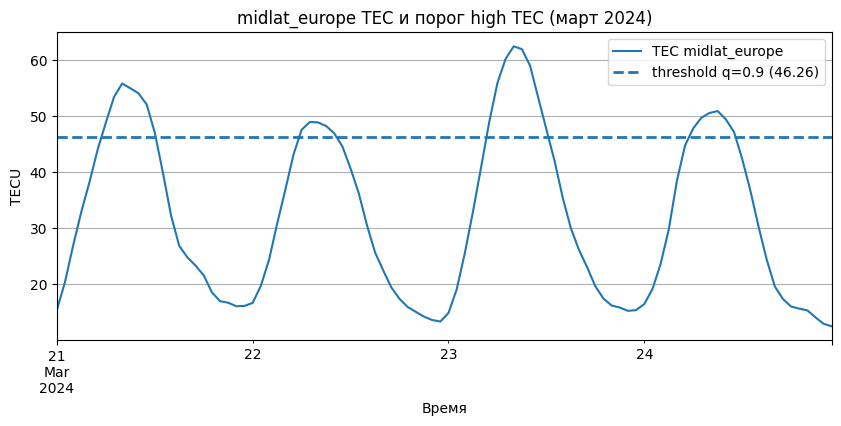

In [ ]:
data = df_ts['midlat_europe']["2024-03-21":"2024-03-24"]


threshold = 46.26

plt.figure(figsize=(10,4))

data.plot(label="TEC midlat_europe")

plt.axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"threshold q=0.9 ({threshold:.2f})"
)

plt.grid(True)
plt.title("midlat_europe TEC и порог high TEC (март 2024)")
plt.xlabel("Время")
plt.ylabel("TECU")
plt.legend()

plt.show()

In [ ]:
TEST_QUERIES = [
    {
        "name": "High TEC / Europe / March 2024 / q=0.9",
        "query": "Find high TEC intervals for midlat_europe in March 2024 using q=0.9.",
        "max_steps": 6,
        "tool_budget": 4,
    },
    {
        "name": "Stable intervals / Europe / March 2024",
        "query": "Find stable TEC intervals for midlat_europe in March 2024.",
        "max_steps": 6,
        "tool_budget": 4,
    },
    {
        "name": "Summary / High latitudes / March 2024",
        "query": "Summarize TEC behavior for highlat_north in March 2024.",
        "max_steps": 6,
        "tool_budget": 4,
    },
    {
        "name": "Compare / Europe vs Equatorial Atlantic / March 2024",
        "query": "Compare TEC behavior in midlat_europe and equatorial_atlantic in March 2024.",
        "max_steps": 8,
        "tool_budget": 5,
    },
    {
        "name": "Compare high TEC / Europe vs North high latitudes / March 2024 / q=0.9",
        "query": "Compare high TEC intervals in midlat_europe and highlat_north in March 2024 using q=0.9.",
        "max_steps": 8,
        "tool_budget": 6,
    },
]


def analyze_run_log(log_text: str, final_output: str) -> dict:
    if not isinstance(log_text, str):
        log_text = str(log_text)

    if not isinstance(final_output, str):
        final_output = str(final_output)

    step_count = len(re.findall(r"MODEL \(step \d+\)", log_text))
    retry_count = len(re.findall(r"MODEL RETRY \(step \d+\)", log_text))
    final_step_count = len(re.findall(r"MODEL \(FINAL STEP\)", log_text))
    final_retry_count = len(re.findall(r"MODEL FINAL RETRY", log_text))
    final_fallback_count = len(re.findall(r"MODEL FINAL FALLBACK", log_text))

    tool_call_count = len(re.findall(r"<tool_call>", log_text))
    final_flag_count = len(re.findall(r"<final_answer>", log_text))

    protocol_error = "[ERROR] Model violated tool-call protocol twice." in final_output
    budget_error = "[ERROR] Tool budget exceeded." in final_output
    unknown_tool_error = "[ERROR] Unknown tool requested by model:" in final_output
    param_error = "[ERROR] Missing required params" in final_output
    max_steps_error = "[ERROR] Max steps reached without final answer." in final_output
    tool_use_during_final_error = "[ERROR] Model attempted tool use during final-answer step." in final_output

    any_error = final_output.startswith("[ERROR]")

    success = not any_error

    return {
        "step_count": step_count,
        "retry_count": retry_count,
        "final_step_count": final_step_count,
        "final_retry_count": final_retry_count,
        "final_fallback_count": final_fallback_count,
        "tool_call_count": tool_call_count,
        "final_flag_count": final_flag_count,
        "protocol_error": protocol_error,
        "budget_error": budget_error,
        "unknown_tool_error": unknown_tool_error,
        "param_error": param_error,
        "max_steps_error": max_steps_error,
        "tool_use_during_final_error": tool_use_during_final_error,
        "success": success,
    }


def run_one_agent_tests(
    test_queries,
    tools_schema,
    max_new_tokens_tool=128,
    max_new_tokens_final=1024,
    max_intervals_compact=8,
    retry_on_invalid_format=True,
    verbose=True,
):
    results = []

    for i, test in enumerate(test_queries, start=1):
        name = test["name"]
        query = test["query"]
        max_steps = test.get("max_steps", 6)
        tool_budget = test.get("tool_budget", 4)

        print("\n" + "=" * 110)
        print(f"TEST {i}/{len(test_queries)}: {name}")
        print(f"QUERY: {query}")
        print("=" * 110)

        log_buffer = io.StringIO()

        try:
            with redirect_stdout(log_buffer):
                out = run_with_tools_native(
                    user_query=query,
                    tools_schema=tools_schema,
                    max_steps=max_steps,
                    tool_budget=tool_budget,
                    verbose=verbose,
                    max_new_tokens_tool=max_new_tokens_tool,
                    max_new_tokens_final=max_new_tokens_final,
                    max_intervals_compact=max_intervals_compact,
                    retry_on_invalid_format=retry_on_invalid_format,
                )

            raw_log = log_buffer.getvalue()
            analysis = analyze_run_log(raw_log, out)

            status = "ok" if analysis["success"] else "error"

        except Exception as e:
            out = f"[EXCEPTION] {type(e).__name__}: {e}"
            raw_log = log_buffer.getvalue()
            analysis = {
                "step_count": None,
                "retry_count": None,
                "final_step_count": None,
                "final_retry_count": None,
                "final_fallback_count": None,
                "tool_call_count": None,
                "final_flag_count": None,
                "protocol_error": False,
                "budget_error": False,
                "unknown_tool_error": False,
                "param_error": False,
                "max_steps_error": False,
                "tool_use_during_final_error": False,
                "success": False,
            }
            status = "exception"

        print(raw_log)
        print("\n--- FINAL OUTPUT ---")
        print(out)

        results.append({
            "name": name,
            "query": query,
            "status": status,
            "output": out,
            "raw_log": raw_log,
            **analysis,
        })

    return results



test_results = run_one_agent_tests(
    test_queries=TEST_QUERIES,
    tools_schema=TOOLS,
    max_new_tokens_tool=128,
    max_new_tokens_final=1024,
    max_intervals_compact=8,
    retry_on_invalid_format=True,
    verbose=True,
)



df_results = pd.DataFrame(test_results)

summary_cols = [
    "name",
    "status",
    "step_count",
    "tool_call_count",
    "retry_count",
    "final_flag_count",
    "final_step_count",
    "final_retry_count",
    "final_fallback_count",
    "protocol_error",
    "budget_error",
    "param_error",
    "max_steps_error",
    "tool_use_during_final_error",
]

print("\n" + "=" * 110)
print("SUMMARY TABLE")
print("=" * 110)
display(df_results[summary_cols])



aggregate = {
    "n_tests": len(df_results),
    "n_success": int(df_results["success"].sum()),
    "n_errors": int((df_results["status"] == "error").sum()),
    "n_exceptions": int((df_results["status"] == "exception").sum()),
    "total_retries": int(df_results["retry_count"].fillna(0).sum()),
    "total_tool_calls": int(df_results["tool_call_count"].fillna(0).sum()),
    "tests_with_retry": int((df_results["retry_count"].fillna(0) > 0).sum()),
    "tests_with_budget_error": int(df_results["budget_error"].fillna(False).sum()),
    "tests_with_protocol_error": int(df_results["protocol_error"].fillna(False).sum()),
    "tests_with_final_fallback": int((df_results["final_fallback_count"].fillna(0) > 0).sum()),
}

print("\n" + "=" * 110)
print("AGGREGATED METRICS")
print("=" * 110)
print(json.dumps(aggregate, ensure_ascii=False, indent=2))



problematic = df_results[df_results["status"] != "ok"]

if len(problematic) > 0:
    print("\n" + "=" * 110)
    print("PROBLEMATIC CASES")
    print("=" * 110)
    display(problematic[[
        "name",
        "status",
        "retry_count",
        "protocol_error",
        "budget_error",
        "param_error",
        "max_steps_error",
        "tool_use_during_final_error",
        "output",
    ]])
else:
    print("\nNo problematic cases found.")



TEST 1/5: High TEC / Europe / March 2024 / q=0.9
QUERY: Find high TEC intervals for midlat_europe in March 2024 using q=0.9.

MODEL (step 1)
<tool_call>
<function=tec_get_timeseries>
<parameter=dataset_ref>
default
</parameter>
<parameter=region>
midlat_europe
</parameter>
<parameter=start>
2024-03-01
</parameter>
<parameter=end>
2024-03-31
</parameter>
</function>
</tool_call>

MODEL (step 2)
<tool_call>
<function=tec_compute_high_threshold>
<parameter=series_id>
025134cc
</parameter>
<parameter=method>
quantile
</parameter>
<parameter=q>
0.9
</parameter>
</function>
</tool_call>

MODEL (step 3)
<tool_call>
<function=tec_detect_high_intervals>
<parameter=series_id>
025134cc
</parameter>
<parameter=threshold_id>
38487e01
</parameter>
</function>
</tool_call>

MODEL (step 4)
<final_answer>

MODEL (FINAL STEP)
High TEC intervals for midlat_europe in March 2024 (q=0.9 threshold: 46.26 TECU):

- 2024-03-11 07:00–08:00 (peak: 47.16, mean: 46.90)
- 2024-03-13 07:00–11:00 (peak: 52.19, mean:

,name,status,step_count,tool_call_count,retry_count,final_flag_count,final_step_count,final_retry_count,final_fallback_count,protocol_error,budget_error,param_error,max_steps_error,tool_use_during_final_error
0,High TEC / Europe / March 2024 / q=0.9,ok,4,3,0,1,1,0,0,False,False,False,False,False
1,Stable intervals / Europe / March 2024,ok,3,2,0,1,1,0,0,False,False,False,False,False
2,Summary / High latitudes / March 2024,error,5,5,0,0,0,0,0,False,True,False,False,False
3,Compare / Europe vs Equatorial Atlantic / Marc...,ok,5,4,0,0,1,0,0,False,False,False,False,False
4,Compare high TEC / Europe vs North high latitu...,error,6,7,1,0,0,0,0,True,False,False,False,False



AGGREGATED METRICS
{
  "n_tests": 5,
  "n_success": 3,
  "n_errors": 2,
  "n_exceptions": 0,
  "total_retries": 1,
  "total_tool_calls": 21,
  "tests_with_retry": 1,
  "tests_with_budget_error": 1,
  "tests_with_protocol_error": 1,
  "tests_with_final_fallback": 0
}

PROBLEMATIC CASES


,name,status,retry_count,protocol_error,budget_error,param_error,max_steps_error,tool_use_during_final_error,output
2,Summary / High latitudes / March 2024,error,0,False,True,False,False,False,[ERROR] Tool budget exceeded. Last requested t...
4,Compare high TEC / Europe vs North high latitu...,error,1,True,False,False,False,False,[ERROR] Model violated tool-call protocol twic...


## Многоагентная сеть

In [ ]:
KNOWN_REGIONS = [
    "midlat_europe",
    "highlat_north",
    "equatorial_atlantic",
]


class TECGraphState(TypedDict, total=False):
    user_query: str

    task_type: str
    regions: List[str]
    start: str
    end: str
    q: float

    series_by_region: Dict[str, str]
    threshold_by_region: Dict[str, str]
    intervals_by_region: Dict[str, Any]
    report_by_region: Dict[str, Any]
    profile_by_region: Dict[str, Any]

    aligned_id: Optional[str]
    comparison_result: Optional[Dict[str, Any]]

    final_answer: Optional[str]
    next_agent: Optional[str]

    trace: List[Dict[str, Any]]
    errors: List[str]


def _ensure_state_defaults(state: TECGraphState) -> TECGraphState:
    s = dict(state)

    s.setdefault("regions", [])
    s.setdefault("series_by_region", {})
    s.setdefault("threshold_by_region", {})
    s.setdefault("intervals_by_region", {})
    s.setdefault("report_by_region", {})
    s.setdefault("profile_by_region", {})
    s.setdefault("aligned_id", None)
    s.setdefault("comparison_result", None)
    s.setdefault("final_answer", None)
    s.setdefault("next_agent", None)
    s.setdefault("trace", [])
    s.setdefault("errors", [])
    s.setdefault("q", 0.9)

    return s


def add_trace(state: TECGraphState, node: str, message: str, **extra) -> TECGraphState:
    s = _ensure_state_defaults(state)
    row = {"node": node, "message": message}
    row.update(extra)
    s["trace"] = s["trace"] + [row]
    return s


def add_error(state: TECGraphState, node: str, error_text: str) -> TECGraphState:
    s = _ensure_state_defaults(state)
    s["errors"] = s["errors"] + [f"{node}: {error_text}"]
    s = add_trace(s, node, "error", error=error_text)
    return s


def extract_regions_from_query(query: str, known_regions: List[str]) -> List[str]:
    q = query.lower()
    found = [r for r in known_regions if r.lower() in q]
    return found


def extract_q_from_query(query: str, default: float = 0.9) -> float:
    m = re.search(r"\bq\s*=\s*([0-9]*\.?[0-9]+)", query.lower())
    if m:
        try:
            return float(m.group(1))
        except Exception:
            pass
    return default


def extract_dates_from_query(query: str):
    q = query.strip()

    m = re.search(r"from\s+(\d{4}-\d{2}-\d{2})\s+to\s+(\d{4}-\d{2}-\d{2})", q, flags=re.IGNORECASE)
    if m:
        return m.group(1), m.group(2)

    month_map = {
        "january": 1,
        "february": 2,
        "march": 3,
        "april": 4,
        "may": 5,
        "june": 6,
        "july": 7,
        "august": 8,
        "september": 9,
        "october": 10,
        "november": 11,
        "december": 12,
    }

    m = re.search(
        r"\bin\s+(january|february|march|april|may|june|july|august|september|october|november|december)\s+(\d{4})",
        q,
        flags=re.IGNORECASE,
    )
    if m:
        month_name = m.group(1).lower()
        year = int(m.group(2))
        month = month_map[month_name]
        last_day = calendar.monthrange(year, month)[1]
        start = f"{year:04d}-{month:02d}-01"
        end = f"{year:04d}-{month:02d}-{last_day:02d}"
        return start, end

    return None, None


def classify_task(query: str) -> str:
    q = query.lower()

    if "compare" in q and "high tec" in q:
        return "compare_high_tec"
    if "compare" in q:
        return "compare_series"
    if "stable" in q or "quiet" in q:
        return "stable_single"
    if "summary" in q or "summarize" in q or "statistics" in q:
        return "summary_single"
    if "high tec" in q:
        return "high_tec_single"

    return "unknown"


def short_json(obj, max_len: int = 300):
    try:
        s = json.dumps(obj, ensure_ascii=False)
    except Exception:
        s = str(obj)
    return s if len(s) <= max_len else s[:max_len] + "..."


def llm_write_final_answer(state: TECGraphState, max_new_tokens: int = 700) -> str:
    payload = {
        "task_type": state.get("task_type"),
        "regions": state.get("regions"),
        "start": state.get("start"),
        "end": state.get("end"),
        "q": state.get("q"),
        "series_by_region": state.get("series_by_region"),
        "threshold_by_region": state.get("threshold_by_region"),
        "intervals_by_region": state.get("intervals_by_region"),
        "report_by_region": state.get("report_by_region"),
        "profile_by_region": state.get("profile_by_region"),
        "aligned_id": state.get("aligned_id"),
        "comparison_result": state.get("comparison_result"),
        "errors": state.get("errors"),
    }

    messages = [
        {
            "role": "system",
            "content": (
                "You are the Reporter agent for a TEC multi-agent system.\n"
                "Write a concise, clear final answer for the user.\n"
                "Do not call tools.\n"
                "Do not mention internal agent names.\n"
                "Do not mention internal handles like series_id or threshold_id.\n"
                "If there are errors, mention them honestly.\n"
            ),
        },
        {
            "role": "user",
            "content": (
                f"Original user query:\n{state.get('user_query', '')}\n\n"
                f"Structured results:\n{json.dumps(payload, ensure_ascii=False, indent=2)}\n\n"
                "Write the final answer."
            ),
        },
    ]

    text = debug_chat_generate_raw(
        messages,
        tools=None,
        max_new_tokens=max_new_tokens,
    )
    return text.strip()


### Агенты

In [ ]:
def orchestrator_agent(state: TECGraphState) -> TECGraphState:
    s = _ensure_state_defaults(state)
    query = s["user_query"]

    task_type = classify_task(query)
    regions = extract_regions_from_query(query, KNOWN_REGIONS)
    start, end = extract_dates_from_query(query)
    q = extract_q_from_query(query, default=0.9)

    s["task_type"] = task_type
    s["regions"] = regions
    s["start"] = start
    s["end"] = end
    s["q"] = q

    if not regions:
        s = add_error(s, "orchestrator", "No known regions were extracted from the query.")
    if not start or not end:
        s = add_error(s, "orchestrator", "Could not parse date range from the query.")
    if task_type == "unknown":
        s = add_error(s, "orchestrator", "Could not classify the task type.")

    if task_type in {"high_tec_single", "stable_single", "summary_single", "compare_series", "compare_high_tec"}:
        s["next_agent"] = "data_agent"
    else:
        s["next_agent"] = "reporter_agent"

    s = add_trace(
        s,
        "orchestrator",
        "task classified",
        task_type=task_type,
        regions=regions,
        start=start,
        end=end,
        q=q,
        next_agent=s["next_agent"],
    )
    return s


In [ ]:
def data_agent(state: TECGraphState) -> TECGraphState:
    s = _ensure_state_defaults(state)

    if s["errors"]:
        s["next_agent"] = "reporter_agent"
        return add_trace(s, "data_agent", "skipped because state already has errors")

    for region in s["regions"]:
        if region in s["series_by_region"]:
            continue

        try:
            result = TOOL_REGISTRY["tec_get_timeseries"](
                dataset_ref="default",
                region=region,
                start=s["start"],
                end=s["end"],
            )
            series_id = result["series_id"]
            s["series_by_region"][region] = series_id
            s = add_trace(
                s,
                "data_agent",
                "loaded series",
                region=region,
                series_id=series_id,
                result=short_json(result),
            )
        except Exception as e:
            s = add_error(s, "data_agent", f"Failed to load series for {region}: {e}")

    if s["errors"]:
        s["next_agent"] = "reporter_agent"
    elif s["task_type"] == "high_tec_single":
        s["next_agent"] = "hightec_agent"
    elif s["task_type"] == "stable_single":
        s["next_agent"] = "stable_agent"
    elif s["task_type"] == "summary_single":
        s["next_agent"] = "summary_agent"
    elif s["task_type"] == "compare_series":
        s["next_agent"] = "compare_agent"
    elif s["task_type"] == "compare_high_tec":
        s["next_agent"] = "hightec_agent"
    else:
        s["next_agent"] = "reporter_agent"

    s = add_trace(s, "data_agent", "routing decided", next_agent=s["next_agent"])
    return s


In [ ]:
def hightec_agent(state: TECGraphState) -> TECGraphState:
    s = _ensure_state_defaults(state)

    if s["errors"]:
        s["next_agent"] = "reporter_agent"
        return add_trace(s, "hightec_agent", "skipped because state already has errors")

    q = s.get("q", 0.9)

    for region in s["regions"]:
        if region in s["intervals_by_region"]:
            continue

        series_id = s["series_by_region"].get(region)
        if not series_id:
            s = add_error(s, "hightec_agent", f"No series_id for region {region}")
            continue

        try:
            thr_result = TOOL_REGISTRY["tec_compute_high_threshold"](
                series_id=series_id,
                method="quantile",
                q=q,
            )
            threshold_id = thr_result["threshold_id"]
            s["threshold_by_region"][region] = threshold_id

            s = add_trace(
                s,
                "hightec_agent",
                "computed high threshold",
                region=region,
                series_id=series_id,
                threshold_id=threshold_id,
                result=short_json(thr_result),
            )

            intervals_result = TOOL_REGISTRY["tec_detect_high_intervals"](
                series_id=series_id,
                threshold_id=threshold_id,
            )
            s["intervals_by_region"][region] = deepcopy(intervals_result)

            s = add_trace(
                s,
                "hightec_agent",
                "detected high intervals",
                region=region,
                result=short_json(intervals_result),
            )
        except Exception as e:
            s = add_error(s, "hightec_agent", f"High TEC pipeline failed for {region}: {e}")

    s["next_agent"] = "reporter_agent"
    s = add_trace(s, "hightec_agent", "routing decided", next_agent=s["next_agent"])
    return s


In [ ]:
def stable_agent(state: TECGraphState) -> TECGraphState:
    s = _ensure_state_defaults(state)

    if s["errors"]:
        s["next_agent"] = "reporter_agent"
        return add_trace(s, "stable_agent", "skipped because state already has errors")

    region = s["regions"][0] if s["regions"] else None
    if not region:
        s = add_error(s, "stable_agent", "No region available")
        s["next_agent"] = "reporter_agent"
        return s

    series_id = s["series_by_region"].get(region)
    if not series_id:
        s = add_error(s, "stable_agent", f"No series_id for region {region}")
        s["next_agent"] = "reporter_agent"
        return s

    try:
        thr_result = TOOL_REGISTRY["tec_compute_stability_thresholds"](
            series_id=series_id
        )
        threshold_id = thr_result["threshold_id"]
        s["threshold_by_region"][region] = threshold_id

        s = add_trace(
            s,
            "stable_agent",
            "computed stability thresholds",
            region=region,
            series_id=series_id,
            threshold_id=threshold_id,
            result=short_json(thr_result),
        )

        intervals_result = TOOL_REGISTRY["tec_detect_stable_intervals"](
            series_id=series_id,
            threshold_id=threshold_id,
        )
        s["intervals_by_region"][region] = deepcopy(intervals_result)

        s = add_trace(
            s,
            "stable_agent",
            "detected stable intervals",
            region=region,
            result=short_json(intervals_result),
        )
    except Exception as e:
        s = add_error(s, "stable_agent", f"Stable TEC pipeline failed for {region}: {e}")

    s["next_agent"] = "reporter_agent"
    s = add_trace(s, "stable_agent", "routing decided", next_agent=s["next_agent"])
    return s


In [ ]:
def summary_agent(state: TECGraphState) -> TECGraphState:
    s = _ensure_state_defaults(state)

    if s["errors"]:
        s["next_agent"] = "reporter_agent"
        return add_trace(s, "summary_agent", "skipped because state already has errors")

    region = s["regions"][0] if s["regions"] else None
    if not region:
        s = add_error(s, "summary_agent", "No region available")
        s["next_agent"] = "reporter_agent"
        return s

    series_id = s["series_by_region"].get(region)
    if not series_id:
        s = add_error(s, "summary_agent", f"No series_id for region {region}")
        s["next_agent"] = "reporter_agent"
        return s

    try:
        report_result = TOOL_REGISTRY["tec_build_report_from_series"](
            series_ids=[series_id],
            include=["basic_stats"],
        )
        s["report_by_region"][region] = deepcopy(report_result)

        s = add_trace(
            s,
            "summary_agent",
            "built report",
            region=region,
            result=short_json(report_result),
        )

        try:
            profile_result = TOOL_REGISTRY["tec_series_profile"](series_id=series_id)
            s["profile_by_region"][region] = deepcopy(profile_result)
            s = add_trace(
                s,
                "summary_agent",
                "built profile",
                region=region,
                result=short_json(profile_result),
            )
        except Exception as inner_e:
            s = add_trace(
                s,
                "summary_agent",
                "profile skipped/failed",
                region=region,
                error=str(inner_e),
            )

    except Exception as e:
        s = add_error(s, "summary_agent", f"Summary pipeline failed for {region}: {e}")

    s["next_agent"] = "reporter_agent"
    s = add_trace(s, "summary_agent", "routing decided", next_agent=s["next_agent"])
    return s


In [ ]:
def compare_agent(state: TECGraphState) -> TECGraphState:
    s = _ensure_state_defaults(state)

    if s["errors"]:
        s["next_agent"] = "reporter_agent"
        return add_trace(s, "compare_agent", "skipped because state already has errors")

    if len(s["regions"]) < 2:
        s = add_error(s, "compare_agent", "Need at least two regions for compare")
        s["next_agent"] = "reporter_agent"
        return s

    try:
        series_ids = [s["series_by_region"][r] for r in s["regions"]]
        align_result = TOOL_REGISTRY["tec_align_series"](
            series_ids=series_ids,
            method="inner",
        )
        aligned_id = align_result["aligned_id"]
        s["aligned_id"] = aligned_id

        s = add_trace(
            s,
            "compare_agent",
            "aligned series",
            aligned_id=aligned_id,
            result=short_json(align_result),
        )

        comp_result = TOOL_REGISTRY["tec_compare_series"](
            aligned_id=aligned_id,
            metrics=["mean", "std", "p90", "max"],
            pairwise=True,
        )
        s["comparison_result"] = deepcopy(comp_result)

        s = add_trace(
            s,
            "compare_agent",
            "computed comparison",
            result=short_json(comp_result),
        )

    except Exception as e:
        s = add_error(s, "compare_agent", f"Compare pipeline failed: {e}")

    s["next_agent"] = "reporter_agent"
    s = add_trace(s, "compare_agent", "routing decided", next_agent=s["next_agent"])
    return s


In [ ]:
def reporter_agent(state: TECGraphState) -> TECGraphState:
    s = _ensure_state_defaults(state)

    try:
        final_answer = llm_write_final_answer(s, max_new_tokens=700)
        s["final_answer"] = final_answer
        s = add_trace(s, "reporter_agent", "final answer generated", final_answer_preview=final_answer[:250])
    except Exception as e:
        s = add_error(s, "reporter_agent", f"Failed to generate final answer: {e}")
        s["final_answer"] = (
            "The workflow completed with errors.\n\n"
            + "\n".join(s["errors"])
        )

    return s

In [ ]:
def route_after_orchestrator(state: TECGraphState) -> str:
    return state.get("next_agent", "reporter_agent")

def route_after_data(state: TECGraphState) -> str:
    return state.get("next_agent", "reporter_agent")


builder = StateGraph(TECGraphState)

builder.add_node("orchestrator_agent", orchestrator_agent)
builder.add_node("data_agent", data_agent)
builder.add_node("hightec_agent", hightec_agent)
builder.add_node("stable_agent", stable_agent)
builder.add_node("summary_agent", summary_agent)
builder.add_node("compare_agent", compare_agent)
builder.add_node("reporter_agent", reporter_agent)

builder.add_edge(START, "orchestrator_agent")

builder.add_conditional_edges(
    "orchestrator_agent",
    route_after_orchestrator,
    {
        "data_agent": "data_agent",
        "reporter_agent": "reporter_agent",
    },
)

builder.add_conditional_edges(
    "data_agent",
    route_after_data,
    {
        "hightec_agent": "hightec_agent",
        "stable_agent": "stable_agent",
        "summary_agent": "summary_agent",
        "compare_agent": "compare_agent",
        "reporter_agent": "reporter_agent",
    },
)

builder.add_edge("hightec_agent", "reporter_agent")
builder.add_edge("stable_agent", "reporter_agent")
builder.add_edge("summary_agent", "reporter_agent")
builder.add_edge("compare_agent", "reporter_agent")

builder.add_edge("reporter_agent", END)

tec_multiagent_graph = builder.compile()
print("LangGraph multi-agent graph compiled.")


LangGraph multi-agent graph compiled.


### Тесты

In [ ]:
test_query = "Compare high TEC intervals in midlat_europe and highlat_north in March 2024 using q=0.9."

initial_state: TECGraphState = {
    "user_query": test_query,
    "trace": [],
    "errors": [],
    "series_by_region": {},
    "threshold_by_region": {},
    "intervals_by_region": {},
    "report_by_region": {},
    "profile_by_region": {},
}

result_state = tec_multiagent_graph.invoke(initial_state)

print("=" * 100)
print("FINAL ANSWER")
print("=" * 100)
print(result_state.get("final_answer", ""))

print("\n" + "=" * 100)
print("TRACE LOG")
print("=" * 100)
for i, row in enumerate(result_state.get("trace", []), start=1):
    print(f"{i:02d}. {json.dumps(row, ensure_ascii=False)}")

print("\n" + "=" * 100)
print("ERRORS")
print("=" * 100)
if result_state.get("errors"):
    for err in result_state["errors"]:
        print("-", err)
else:
    print("No errors.")


FINAL ANSWER
In March 2024, high TEC intervals (q=0.9) were detected in both midlat_europe and highlat_north, but the regions showed distinct characteristics:

*   **midlat_europe:** Experienced 13 high TEC intervals throughout the month, with peak TEC values ranging from approximately 47 to 62 TECU. The most significant event occurred on March 23rd, peaking at 62.49 TECU.
*   **highlat_north:** Recorded only 6 high TEC intervals, with peak TEC values significantly lower, ranging from approximately 27 to 31 TECU. The highest peak in this region was 30.96 TECU on March 28th.

Overall, midlat_europe exhibited more frequent and intense high TEC activity compared to highlat_north during this period.

TRACE LOG
01. {"node": "orchestrator", "message": "task classified", "task_type": "compare_high_tec", "regions": ["midlat_europe", "highlat_north"], "start": "2024-03-01", "end": "2024-03-31", "q": 0.9, "next_agent": "data_agent"}
02. {"node": "data_agent", "message": "loaded series", "region"